In [37]:
from collections import deque
import torch
import matplotlib.pyplot as plt
from VQ_VAE import VQVAE
from galaxy_dataset import get_dataloader

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
embedding_dim = 64
num_embeddings = 1024
commitment = 1
learning_rate = 1e-4
epochs = 100
batch_size = 128

model = VQVAE(embedding_dim, num_embeddings, commitment)

model.load_state_dict(torch.load('vae_checkpoint_v1.pth', weights_only=True))

<All keys matched successfully>

In [39]:
image_folder = 'training_images'
image_size = (128, 128)

train_loader = get_dataloader(image_folder, image_size, batch_size, n=200000)

In [40]:
seen_images = deque(maxlen=10)

for batch in train_loader:
    for img in batch:
        seen_images.append(img)
    break

seen_images = torch.stack(list(seen_images))

test_loader = get_dataloader(image_folder, image_size, batch_size, n=200100)

unseen_images = deque(maxlen=10)

i = 1
for batch in test_loader:
    if i < len(test_loader):
        i += 1
        continue
    for img in batch:
        unseen_images.append(img)

unseen_images = torch.stack(list(unseen_images))

In [41]:
seen_reconstructions, *_ = model(seen_images)
unseen_reconstructions, *_ = model(unseen_images)

seen_images = seen_images.permute(0, 2, 3, 1)
unseen_images = unseen_images.permute(0, 2, 3, 1)

seen_reconstructions = seen_reconstructions.permute(0, 2, 3, 1).detach().numpy()
unseen_reconstructions = unseen_reconstructions.permute(0, 2, 3, 1).detach().numpy()

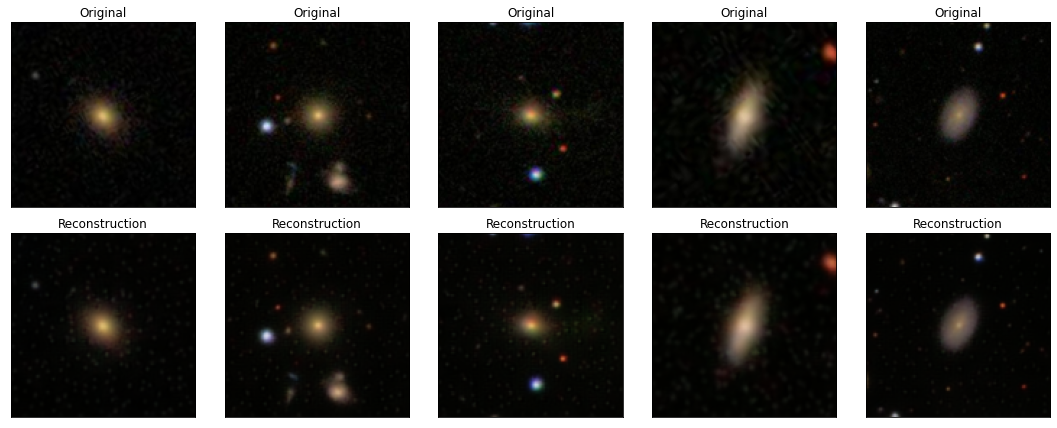

In [42]:
fig, ax = plt.subplots(2, 5, figsize=(15, 6), facecolor='white')

for i in range(5):
    ax[0][i].set_title('Original')
    ax[0][i].imshow(seen_images[i])
    ax[1][i].set_title('Reconstruction')
    ax[1][i].imshow(seen_reconstructions[i])

for row in ax:
    for figure in row:
        figure.set_xticks([])
        figure.set_yticks([])

fig.tight_layout()

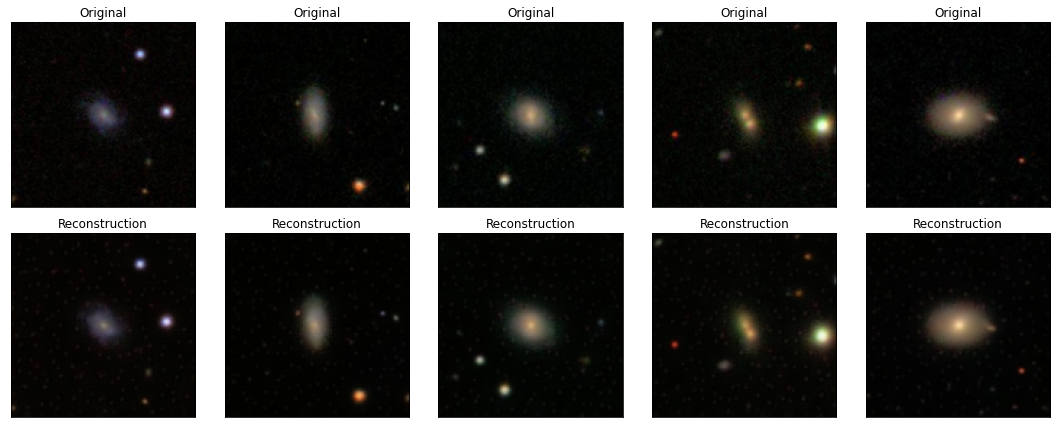

In [34]:
fig, ax = plt.subplots(2, 5, figsize=(15, 6), facecolor='white')

for i in range(5):
    ax[0][i].set_title('Original')
    ax[0][i].imshow(unseen_images[i])
    ax[1][i].set_title('Reconstruction')
    ax[1][i].imshow(unseen_reconstructions[i])

for row in ax:
    for figure in row:
        figure.set_xticks([])
        figure.set_yticks([])

fig.tight_layout()

In [35]:
def sample_vqvae(vae, device, num_samples=4):
    vae.eval()

    with torch.no_grad():
        # Get embedding info
        codebook = vae.vq.embedding.weight  # shape: [num_embeddings, embedding_dim]
        num_embeddings = vae.vq.num_embeddings
        embedding_dim = vae.vq.embedding_dim

        # Determine spatial dimensions expected by decoder
        dummy = torch.randn(1, 3, 128, 128).to(device)
        with torch.no_grad():
            z_e = vae.encoder(dummy)
            _, C, H, W = z_e.shape  # latent spatial shape

        # 1. Sample random indices
        rand_indices = torch.randint(0, num_embeddings, (num_samples, H, W), device=device)  # [B, H, W]

        # 2. Convert to embeddings
        z_q = codebook[rand_indices]  # [B, H, W, C]
        z_q = z_q.permute(0, 3, 1, 2).contiguous()  # [B, C, H, W]

        # 3. Decode
        generated = vae.decoder(z_q)  # [B, 3, 128, 128]
        return generated